## 0. 실습 환경 준비

먼저 현재 노트북 커널에서 필요한 라이브러리를 사용할 수 있는지 확인합니다.

macOS에서 Homebrew Python을 사용하는 경우, 노트북 안에서 `pip install`을 바로 실행하면 `externally-managed-environment` 에러가 날 수 있습니다. 그래서 이 노트북에서는 첫 셀에서 패키지를 강제로 설치하지 않고, 현재 환경을 점검한 뒤 필요한 경우 설치 방법을 안내합니다.

패키지가 없다고 나오면 터미널에서 가상환경을 만든 뒤, 그 가상환경을 노트북 커널로 선택하는 방식이 가장 안전합니다.

In [ ]:
!pip install mlflow scikit-learn pandas matplotlib

## 1. 왜 MLflow가 필요할까?

머신러닝 모델 개발은 보통 한 번에 끝나지 않습니다.

예를 들어 다음과 같은 실험을 여러 번 반복합니다.

- 모델 종류를 바꿔본다.
- 하이퍼파라미터 값을 바꿔본다.
- 데이터 전처리 방법을 바꿔본다.
- 성능 지표를 비교한다.

이때 매번 어떤 설정으로 학습했는지, 정확도가 얼마였는지, 어떤 모델 파일이 만들어졌는지를 손으로 기록하면 매우 번거롭습니다.

MLflow는 이런 실험 기록을 자동으로 남겨주는 도구입니다.

> 초보자 관점에서는 MLflow를 **머신러닝 실험을 위한 실험 노트**라고 이해하면 됩니다.

## 2. MLflow 기본 용어

처음에는 아래 용어만 이해하면 충분합니다.

- **Experiment**: 큰 실험 주제입니다. 예: `digit_classification`
- **Run**: 한 번의 모델 학습 실행입니다.
- **Parameter**: 모델을 학습할 때 사용한 설정값입니다. 예: `max_depth`, `n_estimators`
- **Metric**: 모델 성능을 나타내는 숫자입니다. 예: `accuracy`, `f1-score`
- **Artifact**: 실험 결과로 저장되는 파일입니다. 예: 모델 파일, 이미지, 리포트

구조를 그림처럼 표현하면 다음과 같습니다.

```text
Experiment: digit_classification
 └── Run: RandomForest_first_run
      ├── Parameters
      ├── Metrics
      └── Artifacts
```

## 3. 먼저 MLflow 없이 모델을 만들어보기

MLflow는 완전히 새로운 머신러닝 도구가 아닙니다.

기존에 작성하던 머신러닝 코드에 실험 기록 기능을 추가해주는 도구에 가깝습니다. 그래서 먼저 MLflow 없이 기본 모델을 만들어보겠습니다.

이번 실습에서는 scikit-learn의 `load_digits` 데이터셋을 사용합니다. 이 데이터는 손글씨 숫자 이미지를 분류하는 예제 데이터셋입니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
# 손글씨 숫자 데이터셋을 불러옵니다.
digits = load_digits()

# X는 모델에 들어갈 입력 데이터입니다.
# y는 각 데이터의 정답 라벨입니다.
X = digits.data
y = digits.target

print("입력 데이터 X의 모양:", X.shape)
print("정답 데이터 y의 모양:", y.shape)
print("분류할 숫자 클래스:", digits.target_names)

입력 데이터 X의 모양: (1797, 64)
정답 데이터 y의 모양: (1797,)
분류할 숫자 클래스: [0 1 2 3 4 5 6 7 8 9]


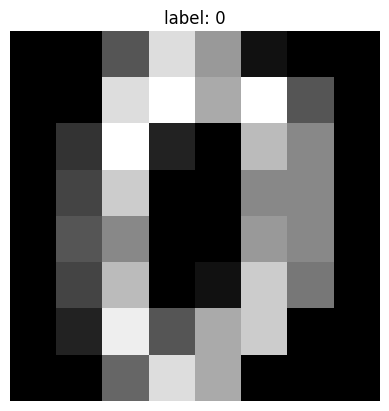

In [3]:
# 데이터가 실제로 어떤 이미지인지 하나만 확인해봅니다.
# digits.images에는 8x8 크기의 손글씨 숫자 이미지가 들어 있습니다.

plt.imshow(digits.images[0], cmap="gray")
plt.title(f"label: {digits.target[0]}")
plt.axis("off")
plt.show()

In [4]:
# 학습용 데이터와 테스트용 데이터를 나눕니다.
# 모델은 X_train, y_train으로 학습하고,
# X_test, y_test로 성능을 확인합니다.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=20,
)

print("학습 데이터 개수:", len(X_train))
print("테스트 데이터 개수:", len(X_test))

학습 데이터 개수: 1347
테스트 데이터 개수: 450


In [5]:
# RandomForestClassifier는 여러 개의 의사결정나무를 사용하는 분류 모델입니다.
# 여기서는 일단 간단한 설정으로 모델을 만들어봅니다.

rf_model = RandomForestClassifier(
    n_estimators=10,   # 사용할 나무의 개수
    max_depth=4,       # 각 나무의 최대 깊이
    criterion="entropy",
    random_state=0,
)

# 모델 학습
rf_model.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
rf_pred = rf_model.predict(X_test)

# 정확도 확인
rf_accuracy = accuracy_score(y_test, rf_pred)
print("RandomForest 정확도:", rf_accuracy)

RandomForest 정확도: 0.8688888888888889


In [6]:
# classification_report는 클래스별 precision, recall, f1-score를 보여줍니다.
# 지금은 모든 지표를 완벽히 이해하지 않아도 됩니다.
# 우선 모델 성능을 여러 관점에서 보여주는 표라고 생각하면 됩니다.

rf_report = classification_report(y_test, rf_pred, output_dict=True)
pd.DataFrame(rf_report).T

,precision,recall,f1-score,support
0,0.937500,1.000000,0.967742,45.000000
1,0.942857,0.733333,0.825000,45.000000
2,0.775000,0.911765,0.837838,34.000000
3,0.829787,0.886364,0.857143,44.000000
4,0.942308,0.960784,0.951456,51.000000
5,0.886364,0.866667,0.876404,45.000000
6,0.868852,0.963636,0.913793,55.000000
7,0.860000,0.914894,0.886598,47.000000
8,0.827586,0.585366,0.685714,41.000000
9,0.795455,0.813953,0.804598,43.000000


## 4. RandomForestClassifier 모델을 MLflow로 기록하기

이제 방금 작성한 모델 학습 코드를 MLflow로 기록해보겠습니다.

아래 코드에서 중요한 부분은 `with mlflow.start_run()`입니다.

이 블록 안에서 실행되는 내용이 하나의 Run으로 기록됩니다.

- `mlflow.log_params()`는 모델 설정값을 기록합니다.
- `mlflow.log_metrics()`는 모델 성능값을 기록합니다.
- `mlflow.sklearn.log_model()`은 학습된 모델 파일을 저장합니다.

In [7]:
import mlflow
import mlflow.sklearn

# 실험 이름을 정합니다.
# 같은 주제의 실험들은 같은 experiment 아래에 모아두면 편리합니다.
experiment_name = "digit_classification"
mlflow.set_experiment(experiment_name)

2026/05/29 13:59:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/29 13:59:14 INFO mlflow.store.db.utils: Updating database tables
2026/05/29 13:59:15 INFO mlflow.tracking.fluent: Experiment with name 'digit_classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/jun05/OneDrive/바탕 화면/BDAI/데이터분석 모델링 (ML모델배포)/week08/mlruns/1', creation_time=1780030756004, experiment_id='1', last_update_time=1780030756004, lifecycle_stage='active', name='digit_classification', tags={}, trace_location=None, workspace='default'>

In [8]:
# 모델 설정값을 dict로 정리합니다.
# 이렇게 정리해두면 MLflow에 한 번에 기록하기 쉽습니다.
rf_params = {
    "n_estimators": 50,
    "max_depth": 5,
    "criterion": "gini",
    "random_state": 20,
}

with mlflow.start_run(
    run_name="RandomForest_run",
    tags={"model": "RandomForestClassifier", "dataset": "digits"},
    description="초보자용 첫 번째 MLflow 실험",
):
    # 1. 모델 생성 및 학습
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train, y_train)

    # 2. 예측 및 성능 계산
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, output_dict=True)

    # 3. MLflow에 기록할 metric을 정리합니다.
    # MLflow metric은 숫자 값으로 기록하는 것이 좋습니다.
    metrics = {
        "accuracy": accuracy,
        "macro_f1_score": report["macro avg"]["f1-score"],
        "weighted_f1_score": report["weighted avg"]["f1-score"],
    }

    # 4. 파라미터와 성능 지표 기록
    mlflow.log_params(rf_params)
    mlflow.log_metrics(metrics)

    # 5. 학습된 모델 저장
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
    )

print("첫 번째 MLflow run 기록 완료")

2026/05/29 13:59:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 13:59:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


첫 번째 MLflow run 기록 완료


## 5. DecisionTreeClassifier 모델 MLflow에 기록하기

In [9]:
# DecisionTree 모델 설정값을 dict로 정리합니다.
# RandomForest와 비슷하게 max_depth, criterion 같은 파라미터를 사용할 수 있습니다.
dt_params = {
    "max_depth": 5,
    "criterion": "gini",
    "random_state": 20,
}

with mlflow.start_run(
    run_name="DecisionTree_run",
    tags={"model": "DecisionTreeClassifier", "dataset": "digits", "purpose": "review"},
    description="복습용 DecisionTree MLflow 실험",
):
    # 1. 모델 생성 및 학습
    model = DecisionTreeClassifier(**dt_params)
    model.fit(X_train, y_train)

    # 2. 예측 및 성능 계산
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, output_dict=True)

    # 3. MLflow에 기록할 metric 정리
    metrics = {
        "accuracy": accuracy,
        "macro_f1_score": report["macro avg"]["f1-score"],
        "weighted_f1_score": report["weighted avg"]["f1-score"],
    }

    # 4. 파라미터와 성능 지표 기록
    mlflow.log_params(dt_params)
    mlflow.log_metrics(metrics)

    # 5. 학습된 DecisionTree 모델 저장
    # DecisionTreeClassifier도 scikit-learn 모델이므로 mlflow.sklearn.log_model()을 사용합니다.
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
    )

print("복습용 DecisionTree MLflow run 기록 완료")
print("DecisionTree 정확도:", accuracy)

2026/05/29 14:00:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 14:00:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


복습용 DecisionTree MLflow run 기록 완료
DecisionTree 정확도: 0.6533333333333333


## 6. MLflow UI에서 확인하기

이제 방금 기록한 실험들을 웹 화면에서 확인해보겠습니다.

터미널에서 현재 노트북이 있는 폴더로 이동한 뒤 아래 명령어를 실행합니다.

```bash
mlflow ui
```

그 다음 브라우저에서 아래 주소로 접속합니다.

```text
http://localhost:5000
```

확인할 항목은 다음과 같습니다.

1. `beginner_digit_classification` Experiment가 있는지 확인합니다.
2. `RandomForest_first_run` Run이 있는지 확인합니다.
3. `DecisionTree_review_run` Run이 있는지 확인합니다.
4. 두 Run의 Parameters에 모델 설정값이 기록되었는지 확인합니다.
5. 두 Run의 Metrics에 정확도와 f1-score가 기록되었는지 확인합니다.
6. 두 Run의 Artifacts에 `model` 폴더가 생성되었는지 확인합니다.

> 여기까지가 1회차의 핵심입니다. MLflow는 모델 학습 결과를 자동으로 정리해주는 실험 노트라고 이해하면 됩니다.

## 1회차 마무리 체크리스트

아래 질문에 답할 수 있으면 1회차 목표를 달성한 것입니다.

- MLflow가 왜 필요한지 설명할 수 있나요?
- Experiment와 Run의 차이를 설명할 수 있나요?
- Parameter와 Metric의 차이를 설명할 수 있나요?
- `with mlflow.start_run()` 안에서 실행한 코드가 하나의 Run으로 기록된다는 점을 이해했나요?
- MLflow UI에서 내가 기록한 실험 결과를 확인할 수 있나요?

다음 2회차에서는 여러 실험을 비교하고, 좋은 모델을 Model Registry에 등록한 뒤 다시 불러오는 흐름을 실습합니다.